# SI - Beam overlap in the Fourier plane

This notebook regenerates the five camera overlays and the coupling/overlap sweep. The camera bundle contains arithmetic averages of the 101 raw frames at each of six source positions; retaining those averages reduces the source camera directory from 110 MB and 606 files to one 2.4 MB array without changing the plotted image.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "DATA_MANIFEST.md").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the reproduction repository.")


ROOT = find_repository_root()
OUTPUT_DIR = ROOT / "figures" / "generated"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Nimbus Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "axes.grid": False,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from scipy.signal import find_peaks


## Load camera averages and lock-in sweeps

In [2]:
camera = np.load(ROOT / "data" / "si_beam_overlap_fourier" / "camera_averages.npz")
labels = camera["labels"]
images = camera["images"]

overlap = np.load(
    ROOT / "data" / "si_beam_overlap_fourier" / "beam_sweep_lockinA_2025-12-10.npy",
    allow_pickle=True,
).item()
coupling = np.load(
    ROOT / "data" / "si_beam_overlap_fourier" / "coupling_sweep_2025-12-10.npy",
    allow_pickle=True,
).item()

x_overlap = np.asarray(overlap["x_meas"], dtype=float)
y_overlap = np.asarray(overlap["lockin_meas"], dtype=float)
x_coupling = np.asarray(coupling["x_meas"], dtype=float)
total_coupling = np.sum(np.asarray(coupling["lockin_meas"], dtype=float)[:, 1:9], axis=1)
print("Camera labels:", labels.tolist())

Camera labels: ['refbeam', 'x4.765', 'x5.308', 'x6.03', 'x6.389', 'x7.23']


## Plot the SI figure

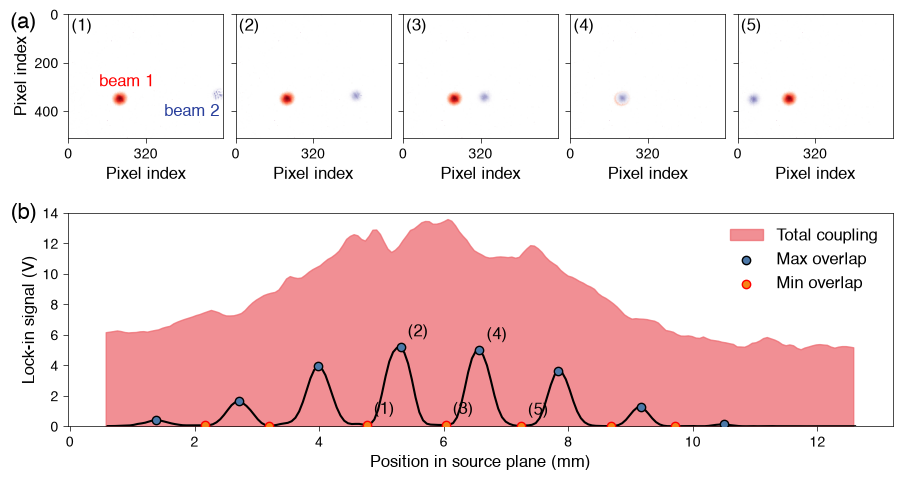

In [3]:
fig = plt.figure(figsize=(8.96, 4.88))
grid = fig.add_gridspec(2, 5, height_ratios=(1.0, 1.65), hspace=0.42, wspace=0.08)

reference = images[0] - images[0].min()
reference_mask = images[0] > 0.4 * images[0].max()
positions = [4.765, 5.308, 6.03, 6.389, 7.23]
for number, axis in enumerate([fig.add_subplot(grid[0, index]) for index in range(5)], start=1):
    moving = images[number] - images[number].min()
    moving_mask = images[number] > 0.4 * images[number].max()
    axis.imshow(reference, cmap="Reds", alpha=reference_mask.astype(float))
    axis.imshow(moving, cmap="Purples", alpha=moving_mask.astype(float))
    axis.set_xticks([0, images.shape[-1] // 2])
    if number == 1:
        axis.set_ylabel("Pixel index")
        axis.text(0.20, 0.42, "beam 1", color="red", transform=axis.transAxes)
        axis.text(0.62, 0.18, "beam 2", color="#293f9c", transform=axis.transAxes)
    else:
        axis.tick_params(labelleft=False)
    axis.set_xlabel("Pixel index")
    axis.text(0.02, 0.97, f"({number})", transform=axis.transAxes, va="top")

ax = fig.add_subplot(grid[1, :])
peaks, _ = find_peaks(y_overlap, prominence=0.05)
dips, _ = find_peaks(-y_overlap, prominence=0.1)
ax.fill_between(x_coupling, total_coupling, color="#ed6a70", alpha=0.75, label="Total coupling")
ax.plot(x_overlap, y_overlap, color="black", linewidth=1.5)
ax.scatter(x_overlap[peaks], y_overlap[peaks], color="#4c78a8", edgecolor="black", zorder=3, label="Max overlap")
ax.scatter(x_overlap[dips], y_overlap[dips], color="#f58518", edgecolor="red", zorder=3, label="Min overlap")
for number, position in enumerate(positions, start=1):
    # The camera positions alternate between destructive- and constructive-
    # overlap settings.  Associate each image with the nearest measured
    # minimum (odd labels) or maximum (even labels), as in the source figure.
    candidates = dips if number % 2 else peaks
    index = int(candidates[np.argmin(np.abs(x_overlap[candidates] - position))])
    ax.annotate(f"({number})", (x_overlap[index], y_overlap[index]), xytext=(5, 8), textcoords="offset points")
ax.set(xlabel="Position in source plane (mm)", ylabel="Lock-in signal (V)", ylim=(0, 14))
ax.legend(loc="upper right")

fig.text(0.005, 0.98, "(a)", fontsize=16, ha="left", va="top")
ax.text(-0.07, 1.05, "(b)", transform=ax.transAxes, fontsize=16, ha="left", va="top")
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.13, top=0.98)
for suffix in ("svg", "png"):
    fig.savefig(OUTPUT_DIR / f"si_beam_overlap_fourier.{suffix}", dpi=300, bbox_inches="tight")
plt.show()